In [3]:
from pathlib import Path
import sys


def find_repo_root(start_dir: Path) -> Path:
    """Find the project root containing data/raw and classification/svm."""
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / "data" / "raw").exists() and (candidate / "classification" / "svm").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find project root containing data/raw and classification/svm from the current working directory."
    )


repo_root = find_repo_root(Path.cwd())

preprocess_dir = repo_root / "classification" / "svm"
if not (preprocess_dir / "preprocess_pipeline.py").exists():
    raise FileNotFoundError(f"Missing preprocess module at: {preprocess_dir / 'preprocess_pipeline.py'}")
if str(preprocess_dir) not in sys.path:
    sys.path.insert(0, str(preprocess_dir))

from preprocess_pipeline import preprocess_excel_file

TEXT_COL = "body_display"
INPUT_PATH = repo_root / "data" / "raw" / "singapore_wp_comments_display.xlsx"
OUTPUT_PATH = repo_root / "data" / "cleaned" / "singapore_wp_comments_display_clean.xlsx"

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Missing input file: {INPUT_PATH}")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df = preprocess_excel_file(INPUT_PATH, text_col=TEXT_COL, output_path=OUTPUT_PATH)
print(df[[TEXT_COL, "clean_text"]].head(10))
print(f"Saved -> {OUTPUT_PATH}")

                                        body_display  \
0  I think it applies for social media in general...   
1  I’m worried that WP is getting over reliant on...   
2  Singapore is too small. You go to where your c...   
3  The problem is that GST reduction is not the o...   
4  Out of all the mosquitoes maybe Hazel Poa and ...   
5  Nah.. Ariffin Sha may seem like a good speaker...   
6  WP won't take mosquitos. They worked so hard t...   
7  Unless WP wants to take the mosquitoes under t...   
8  It's not a given for WP to win the by-election...   
9  I think SDP is too far to the left for fiscall...   

                                          clean_text  
0  i think it applies for social media in general...  
1  i ’ m worried that workers party is getting ov...  
2  singapore is too small. you go to where your c...  
3  the problem is that gst reduction is not the o...  
4  out of all the mosquitoes maybe hazel poa and ...  
5  nah.. ariffin sha may seem like a good speaker... 

In [5]:
"""
Two-stage sentiment pipeline for Singapore political Reddit data.

Flow:
1) Load preprocessed input from Cell 1 output
2) Stage 1: subjectivity filter (objective -> Neutral)
3) Stage 2: SVM sentiment classification (subjective only)
4) Entity/aspect enrichment and optional sarcasm soft-adjustment
5) Save CSV and JSON outputs
"""

import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# ===============================
# SECTION 0 - OPTIONAL BACKENDS
# ===============================
# spaCy and NLTK are optional. The pipeline falls back safely if unavailable.
SPACY_NLP = None
NLTK_LESK = None

try:
    import spacy
    SPACY_NLP = spacy.load("en_core_web_sm")
    print("[setup] spaCy loaded (en_core_web_sm)")
except Exception:
    print("[setup] spaCy not available - using regex-only NER")

try:
    from nltk.wsd import lesk as _lesk
    NLTK_LESK = _lesk
    print("[setup] NLTK lesk loaded")
except Exception:
    print("[setup] NLTK lesk not available - using default aspect mapping")


# =====================================
# SECTION 1 - LOAD DATA AND ARTIFACTS
# =====================================
def find_repo_root(start_dir: Path) -> Path:
    """Find project root containing data/cleaned and classification/svm."""
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / "data" / "cleaned").exists() and (candidate / "classification" / "svm").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find project root containing data/cleaned and classification/svm from the current working directory."
    )


repo_root = find_repo_root(Path.cwd())
DATA_PATH = repo_root / "data" / "cleaned" / "singapore_wp_comments_display_clean.xlsx"
TEXT_COL = "clean_text"
RAW_COL = "body_display"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find cleaned inference input: {DATA_PATH}. Run notebook Cell 1 first."
    )

df = pd.read_excel(DATA_PATH)

if RAW_COL not in df.columns:
    raise ValueError(f"Missing required column: '{RAW_COL}'")

# Fallback for datasets where clean_text is absent.
if TEXT_COL not in df.columns:
    df[TEXT_COL] = df[RAW_COL]
    print(f"[warn] '{TEXT_COL}' not found - using '{RAW_COL}' as fallback")

df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[RAW_COL] = df[RAW_COL].fillna("").astype(str)

print(f"[load] Dataset: {len(df):,} rows from {DATA_PATH}")

ARTIFACTS_DIR = repo_root / "classification" / "svm" / "model_artifacts"
for pkl_name, pkl_path, var_name in [
    ("TF-IDF", ARTIFACTS_DIR / "tfidf.pkl", "tfidf_vectorizer"),
    ("SVM model", ARTIFACTS_DIR / "svm_model.pkl", "svm_model"),
]:
    if not pkl_path.exists():
        raise FileNotFoundError(
            f"Missing {pkl_name} pickle at {pkl_path}. Run notebook Step 2 first."
        )
    with open(pkl_path, "rb") as f:
        globals()[var_name] = pickle.load(f)
    print(f"[load] {pkl_name} loaded from {pkl_path}")


# ============================
# SECTION 2 - KNOWLEDGE BASE
# ============================
PARTY_ALIAS_TO_CANONICAL = {
    "wp": "Workers Party",
    "workers party": "Workers Party",
    "worker party": "Workers Party",
    "workers' party": "Workers Party",
    "pap": "Peoples Action Party",
    "people action party": "Peoples Action Party",
    "people's action party": "Peoples Action Party",
    "psp": "Progress Singapore Party",
    "progress singapore party": "Progress Singapore Party",
    "sdp": "Singapore Democratic Party",
    "singapore democratic party": "Singapore Democratic Party",
    "rp": "Reform Party",
    "reform party": "Reform Party",
    "rdu": "Red Dot United",
    "red dot united": "Red Dot United",
}

PERSON_ALIAS_TO_CANONICAL = {
    "pritam": "Pritam Singh",
    "ps": "Pritam Singh",
    "pritam singh": "Pritam Singh",
    "sylvia": "Sylvia Lim",
    "sylvia lim": "Sylvia Lim",
    "jamus": "Jamus Lim",
    "jamus lim": "Jamus Lim",
    "he ting ru": "He Ting Ru",
    "ting ru": "He Ting Ru",
    "gerald": "Gerald Giam",
    "gerald giam": "Gerald Giam",
    "lee hsien loong": "Lee Hsien Loong",
    "lhl": "Lee Hsien Loong",
    "pm lee": "Lee Hsien Loong",
    "lee kuan yew": "Lee Kuan Yew",
    "lky": "Lee Kuan Yew",
    "lawrence wong": "Lawrence Wong",
    "lw": "Lawrence Wong",
    "pm wong": "Lawrence Wong",
    "vivian": "Vivian Balakrishnan",
    "vivian balakrishnan": "Vivian Balakrishnan",
    "chan chun sing": "Chan Chun Sing",
    "ccs": "Chan Chun Sing",
    "ong ye kung": "Ong Ye Kung",
    "oyk": "Ong Ye Kung",
}

PERSON_TO_PARTY = {
    "Pritam Singh": "Workers Party",
    "Sylvia Lim": "Workers Party",
    "Jamus Lim": "Workers Party",
    "He Ting Ru": "Workers Party",
    "Gerald Giam": "Workers Party",
    "Lee Hsien Loong": "Peoples Action Party",
    "Lee Kuan Yew": "Peoples Action Party",
    "Lawrence Wong": "Peoples Action Party",
    "Vivian Balakrishnan": "Peoples Action Party",
    "Chan Chun Sing": "Peoples Action Party",
    "Ong Ye Kung": "Peoples Action Party",
}

ASPECTS = {
    "economy": [
        "economy", "economic", "inflation", "cost", "price", "gst", "tax",
        "cost of living", "jobs", "salary", "wage", "business", "foreign policy",
    ],
    "housing": [
        "hdb", "housing", "rent", "property", "bto", "mortgage", "home", "flat",
    ],
    "government": [
        "policy", "minister", "government", "parliament", "leadership", "governance",
    ],
}

# Ambiguous tokens that may map to multiple aspects.
AMBIGUOUS_TERMS = {
    "policy": "government",
    "cost": "economy",
    "property": "housing",
}

PRONOUN_PERSON = {"he", "him", "his", "she", "her", "hers"}
PRONOUN_GROUP = {"they", "them", "their", "theirs"}

SARCASTIC_MARKERS = {
    "yeah right", "as if", "sure", "totally", "obviously", "/s", "lol", "lmao"
}

SUBJECTIVE_CUES = {
    "i think", "i feel", "i guess", "in my opinion", "seems",
    "looks like", "probably",
}

# Texts below this score are treated as objective and set to Neutral.
SUBJECTIVITY_THRESHOLD = 0.05


# ============================
# SECTION 3 - TEXT UTILITIES
# ============================
def normalize_text(text: str) -> str:
    """Lowercase and normalize text for matching."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-']", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _compile_term_pattern(term: str, allow_hyphen_suffix: bool = False) -> re.Pattern:
    """Create a whole-word regex for a term."""
    term_norm = normalize_text(term)
    if not term_norm:
        return re.compile(r"a^")
    phrase = re.escape(term_norm).replace(r"\ ", r"\s+")
    suffix = r"(?:-[a-z0-9]+)*" if allow_hyphen_suffix else ""
    return re.compile(
        rf"(?<![a-z0-9]){phrase}{suffix}(?![a-z0-9])",
        flags=re.IGNORECASE,
    )


def _unique_preserve_order(items: list) -> list:
    """Deduplicate while keeping first-seen order."""
    return list(dict.fromkeys(items))


def split_sentences(text: str) -> list[str]:
    """Split text into sentences via spaCy if available, regex otherwise."""
    if not text:
        return []
    if SPACY_NLP is not None:
        sents = [s.text.strip() for s in SPACY_NLP(text).sents if s.text.strip()]
        return sents or [text]
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p for p in parts if p]


# Compile once to avoid repeated regex compilation in loops.
PERSON_PATTERNS = {
    alias: _compile_term_pattern(alias)
    for alias in PERSON_ALIAS_TO_CANONICAL
}
PARTY_PATTERNS = {
    alias: _compile_term_pattern(
        alias,
        allow_hyphen_suffix=(alias.isupper() and alias.isalpha()),
    )
    for alias in PARTY_ALIAS_TO_CANONICAL
}
ASPECT_PATTERNS = {
    aspect: [_compile_term_pattern(kw) for kw in keywords]
    for aspect, keywords in ASPECTS.items()
}


# ========================================
# SECTION 4 - STAGE 1 SUBJECTIVITY FILTER
# ========================================
def subjectivity_score(text: str) -> float:
    """Compute a heuristic subjectivity score in [0, 1]."""
    t = text.lower()
    score = 0.4 if any(cue in t for cue in SUBJECTIVE_CUES) else 0.0
    pronouns = len(re.findall(r"\b(i|me|my|we|our)\b", t))
    score += min(0.6, pronouns * 0.1)
    return round(min(score, 1.0), 4)


def is_subjective(text: str) -> bool:
    """Return True when text passes the subjectivity threshold."""
    return subjectivity_score(text) >= SUBJECTIVITY_THRESHOLD


# ======================================
# SECTION 5 - STAGE 2 SVM CLASSIFICATION
# ======================================
def classify_sentiment_batch(texts: list[str]) -> tuple[list[str], list[float]]:
    """Predict sentiment labels and confidence scores for a batch of texts."""
    if not texts:
        return [], []

    safe = [t if isinstance(t, str) else "" for t in texts]
    X = tfidf_vectorizer.transform(safe)
    preds = svm_model.predict(X)

    if hasattr(svm_model, "predict_proba"):
        probs = svm_model.predict_proba(X)
        confidences = probs.max(axis=1).astype(float)
    elif hasattr(svm_model, "decision_function"):
        margins = np.asarray(svm_model.decision_function(X))
        raw = margins.max(axis=1) if margins.ndim > 1 else margins.astype(float)
        confidences = 1.0 / (1.0 + np.exp(-raw))
    else:
        confidences = np.ones(len(safe), dtype=float)

    return [str(p) for p in preds], [round(float(c), 4) for c in confidences]


def classify_sentiment(text: str) -> tuple[str, float]:
    """Single-text wrapper for classify_sentiment_batch."""
    labels, scores = classify_sentiment_batch([text])
    return (labels[0], scores[0]) if labels else ("Neutral", 0.0)


# ===============================
# SECTION 6 - FEATURE ENRICHMENT
# ===============================
def disambiguate_aspect_term(term: str, sentence: str) -> str:
    """Resolve ambiguous aspect terms with NLTK lesk when available."""
    default = AMBIGUOUS_TERMS.get(term.lower())
    if default is None:
        return None
    if NLTK_LESK is None:
        return default

    try:
        context = sentence.lower().split()
        syn = NLTK_LESK(context, term.lower())
        if syn is None:
            return default
        lexname = syn.lexname()
        if term.lower() == "property" and ("possession" in lexname or "location" in lexname):
            return "housing"
        if term.lower() == "policy" and ("cognition" in lexname or "communication" in lexname):
            return "government"
        if term.lower() == "cost" and ("quantity" in lexname or "possession" in lexname):
            return "economy"
    except Exception:
        return default
    return default


def _regex_entity_matches(text_norm: str, patterns: dict, canonical_map: dict) -> list[str]:
    """Match aliases with regex and return canonical names in text order."""
    hits = []
    for alias, pat in patterns.items():
        m = pat.search(text_norm)
        if m:
            hits.append((m.start(), canonical_map[alias]))
    hits.sort(key=lambda x: x[0])
    return [name for _, name in hits]


def _ner_entity_matches(sentence: str) -> tuple[list[str], list[str]]:
    """Supplement regex extraction with spaCy PERSON/ORG/GPE entities."""
    if SPACY_NLP is None or not sentence:
        return [], []
    doc = SPACY_NLP(sentence)
    persons = [e.text for e in doc.ents if e.label_ == "PERSON"]
    orgs = [e.text for e in doc.ents if e.label_ in {"ORG", "GPE"}]
    return persons, orgs


def _canonicalise_ner(ner_values: list[str], alias_map: dict) -> list[str]:
    """Map raw NER strings to canonical names via alias lookup."""
    out = []
    for val in ner_values:
        v_norm = normalize_text(val)
        if v_norm in alias_map:
            out.append(alias_map[v_norm])
            continue
        for alias, canonical in alias_map.items():
            if alias in v_norm or v_norm in alias:
                out.append(canonical)
                break
    return out


def extract_entities_and_aspects(clean_text: str) -> tuple[list, list, list]:
    """Extract persons, parties, and aspects from clean text."""
    if not clean_text or not clean_text.strip():
        return [], [], []

    sentences = split_sentences(clean_text)
    all_persons, all_parties, all_aspects = [], [], []

    # Track recent entities for simple pronoun backfill across sentences.
    last_person = None
    last_party = None

    for sent in sentences:
        sent_norm = normalize_text(sent)

        persons = _regex_entity_matches(sent_norm, PERSON_PATTERNS, PERSON_ALIAS_TO_CANONICAL)
        parties = _regex_entity_matches(sent_norm, PARTY_PATTERNS, PARTY_ALIAS_TO_CANONICAL)

        ner_p, ner_o = _ner_entity_matches(sent)
        persons += _canonicalise_ner(ner_p, PERSON_ALIAS_TO_CANONICAL)
        parties += _canonicalise_ner(ner_o, PARTY_ALIAS_TO_CANONICAL)

        persons = _unique_preserve_order(persons)
        parties = _unique_preserve_order(parties)

        for person in persons:
            party = PERSON_TO_PARTY.get(person)
            if party:
                parties.append(party)
        parties = _unique_preserve_order(parties)

        tokens = set(sent_norm.split())
        if not persons and any(p in tokens for p in PRONOUN_PERSON) and last_person:
            persons.append(last_person)
            inferred = PERSON_TO_PARTY.get(last_person)
            if inferred:
                parties.append(inferred)
        if not parties and any(p in tokens for p in PRONOUN_GROUP) and last_party:
            parties.append(last_party)

        persons = _unique_preserve_order(persons)
        parties = _unique_preserve_order(parties)

        aspects = []
        for aspect, patterns in ASPECT_PATTERNS.items():
            if any(p.search(sent_norm) for p in patterns):
                aspects.append(aspect)
        for term in AMBIGUOUS_TERMS:
            if _compile_term_pattern(term).search(sent_norm):
                resolved = disambiguate_aspect_term(term, sent_norm)
                if resolved:
                    aspects.append(resolved)
        aspects = _unique_preserve_order(aspects)

        all_persons.extend(persons)
        all_parties.extend(parties)
        all_aspects.extend(aspects)

        if persons:
            last_person = persons[-1]
        if parties:
            last_party = parties[-1]

    return (
        _unique_preserve_order(all_persons),
        _unique_preserve_order(all_parties),
        _unique_preserve_order(all_aspects),
    )


def detect_sarcasm(text: str) -> bool:
    """Heuristic sarcasm detector for low-confidence soft adjustment."""
    t = text.lower()
    if any(marker in t for marker in SARCASTIC_MARKERS):
        return True
    if t.count("!") >= 3 or t.count("?") >= 3:
        return True
    if re.search(r'"[^"]+"', text):
        return True
    return False


# =====================================
# SECTION 7 - MAIN PIPELINE ORCHESTRATOR
# =====================================
def process_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """Run subjectivity filter, SVM inference, enrichment, and return results."""
    texts = df[TEXT_COL].tolist()
    n = len(texts)
    print(f"\n[pipeline] Processing {n:,} texts ...")

    print("[stage 1] Computing subjectivity scores ...")
    subj_scores = [subjectivity_score(t) for t in texts]
    is_subj_mask = [s >= SUBJECTIVITY_THRESHOLD for s in subj_scores]

    objective_count = sum(1 for v in is_subj_mask if not v)
    subjective_count = sum(is_subj_mask)
    print(
        f"[stage 1] Objective (-> Neutral): {objective_count:,}  |  "
        f"Subjective (-> SVM): {subjective_count:,}"
    )

    # Initialize with Neutral; overwrite subjective rows after SVM inference.
    sentiment_labels = ["Neutral"] * n
    sentiment_scores = [0.0] * n

    print("[stage 2] Classifying subjective texts with SVM ...")
    subjective_indices = [i for i, v in enumerate(is_subj_mask) if v]
    subjective_texts = [texts[i] for i in subjective_indices]

    if subjective_texts:
        svm_labels, svm_conf = classify_sentiment_batch(subjective_texts)
        for idx, label, score in zip(subjective_indices, svm_labels, svm_conf):
            sentiment_labels[idx] = label
            sentiment_scores[idx] = score

    print("[enrich] Extracting entities and aspects ...")
    persons_col = []
    parties_col = []
    aspects_col = []

    for txt in texts:
        persons, parties, aspects = extract_entities_and_aspects(txt)
        persons_col.append(persons)
        parties_col.append(parties)
        aspects_col.append(aspects)

    # Soft adjustment: reduce confidence for likely sarcastic low-confidence rows.
    print("[enrich] Applying sarcasm adjustment ...")
    sarcasm_flags = [detect_sarcasm(t) for t in texts]

    adjusted = 0
    for i in range(n):
        if sarcasm_flags[i]:
            if sentiment_scores[i] < 0.5:
                sentiment_scores[i] = round(sentiment_scores[i] * 0.7, 4)
                adjusted += 1
            elif 0.5 <= sentiment_scores[i] < 0.6:
                sentiment_scores[i] = round(sentiment_scores[i] * 0.85, 4)
                adjusted += 1

    print(f"[enrich] Sarcasm-adjusted labels (soft): {adjusted:,}")

    results = pd.DataFrame({
        "text": df[RAW_COL].values,
        "clean_text": df[TEXT_COL].values,
        "sentiment": sentiment_labels,
        "sentiment_score": sentiment_scores,
        "party": parties_col,
        "person": persons_col,
        "aspect": aspects_col,
    })

    print("\n[pipeline] Sentiment distribution:")
    print(results["sentiment"].value_counts().to_string())
    print(f"\n[pipeline] spaCy NER enabled : {SPACY_NLP is not None}")
    print(f"[pipeline] NLTK lesk enabled : {NLTK_LESK is not None}")

    return results


# ===========================
# SECTION 8 - RUN AND EXPORT
# ===========================
if __name__ == "__main__":
    df_results = process_pipeline(df)

    OUTPUT_DIR = repo_root / "data" / "cleaned"
    OUTPUT_CSV = OUTPUT_DIR / "singapore_wp_comments_display_inference.csv"
    OUTPUT_JSON = OUTPUT_DIR / "singapore_wp_comments_display_inference.json"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    df_results.to_csv(OUTPUT_CSV, index=False)
    df_results.to_json(
        OUTPUT_JSON,
        orient="records",
        indent=2,
        force_ascii=False,
    )

    print(f"\n[done] Saved {OUTPUT_CSV} and {OUTPUT_JSON}")
    print(f"[done] Total rows : {len(df_results):,}")
    print(df_results.head(10).to_string())

[setup] spaCy loaded (en_core_web_sm)
[setup] NLTK lesk loaded
[load] Dataset: 13,214 rows from C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\data\cleaned\singapore_wp_comments_display_clean.xlsx
[load] TF-IDF loaded from C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\classification\svm\model_artifacts\tfidf.pkl
[load] SVM model loaded from C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\classification\svm\model_artifacts\svm_model.pkl

[pipeline] Processing 13,214 texts ...
[stage 1] Computing subjectivity scores ...


C:\Users\polir\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\polir\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\polir\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.8.0 when using version 1.5.1. This might lead to breaking c

[stage 1] Objective (-> Neutral): 5,489  |  Subjective (-> SVM): 7,725
[stage 2] Classifying subjective texts with SVM ...
[enrich] Extracting entities and aspects ...
[enrich] Applying sarcasm adjustment ...
[enrich] Sarcasm-adjusted labels (soft): 3,061

[pipeline] Sentiment distribution:
sentiment
Neutral     6986
Positive    5946
Negative     282

[pipeline] spaCy NER enabled : True
[pipeline] NLTK lesk enabled : True

[done] Saved C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\data\cleaned\singapore_wp_comments_display_inference.csv and C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\data\cleaned\singapore_wp_comments_display_inference.json
[done] Total rows : 13,214
                                                                                                                                                                                                                                                                                                                    

In [7]:
### ===========================
# SECTION 10 - PERFORMANCE BENCHMARK
# ===========================
import time
import sys
preprocess_dir = repo_root / "classification" / "svm"
if str(preprocess_dir) not in sys.path:
    sys.path.insert(0, str(preprocess_dir))
from preprocess_pipeline import preprocess_text

print("\n=== Performance Benchmark ===")
print(f"{'Batch Size':>12} | {'Preprocess (s)':>14} | {'Inference (s)':>13} | {'Total (s)':>9} | {'Records/sec':>12}")
print("-" * 72)

batch_sizes = [100, 500, 1000, 5000, 10000, len(df)]

for size in batch_sizes:
    # Simulate batch by resizing available data
    sample = pd.Series(np.resize(df[TEXT_COL].values, size))

    # Preprocessing time
    start = time.perf_counter()
    cleaned = sample.map(preprocess_text)
    preprocess_time = time.perf_counter() - start

    # Inference time only
    start = time.perf_counter()
    X_vec = tfidf_vectorizer.transform(cleaned)
    _ = svm_model.predict(X_vec)
    inference_time = time.perf_counter() - start

    total = preprocess_time + inference_time
    rps = size / total

    # Print one line per batch size only
    print(f"{size:>12,} | {preprocess_time:>14.4f} | {inference_time:>13.4f} | {total:>9.4f} | {rps:>12.1f}")


=== Performance Benchmark ===
  Batch Size | Preprocess (s) | Inference (s) | Total (s) |  Records/sec
------------------------------------------------------------------------
         100 |         0.0923 |        0.0289 |    0.1212 |        824.9
         500 |         0.4062 |        0.1260 |    0.5322 |        939.4
       1,000 |         0.7876 |        0.2375 |    1.0251 |        975.5
       5,000 |         4.4793 |        1.0709 |    5.5502 |        900.9
      10,000 |         8.7756 |        2.4183 |   11.1939 |        893.3
      13,214 |        12.4813 |        3.1166 |   15.5979 |        847.2


In [19]:
# ===========================
# SECTION 11 - ABLATION STUDY
# ===========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# -------------------------------------------------------
# Load ground truth and reproduce the exact test split
# from your training notebook (test_size=0.2, random_state=42)
# -------------------------------------------------------
EVAL_PATH = repo_root / "data" / "cleaned" / "data_annotation_clean.csv"
eval_df = pd.read_csv(EVAL_PATH).dropna(subset=["clean_text", "manual_labelling"]).copy()
eval_df["clean_text"]       = eval_df["clean_text"].astype(str).str.strip()
eval_df["manual_labelling"] = eval_df["manual_labelling"].astype(str).str.strip()
eval_df = eval_df[
    (eval_df["clean_text"] != "") & (eval_df["manual_labelling"] != "")
]

# Reproduce exact same split as training notebook
_, X_test_df, _, y_test_series = train_test_split(
    eval_df[["clean_text"]],
    eval_df["manual_labelling"],
    test_size=0.2,
    stratify=eval_df["manual_labelling"],
    random_state=42,
)

texts  = X_test_df["clean_text"].tolist()
y_true = y_test_series.tolist()

print(f"Ablation running on held-out test set: {len(texts)} records")
print(f"Class distribution:\n{y_test_series.value_counts()}\n")

# -------------------------------------------------------
# Base SVM predictions shared across all configurations
# -------------------------------------------------------
base_labels, base_scores = classify_sentiment_batch(texts)

# -------------------------------------------------------
# Configuration 1 — Baseline
# -------------------------------------------------------
config_1_baseline = base_labels.copy()

# -------------------------------------------------------
# Configuration 2 — Sarcasm only
# -------------------------------------------------------
SARCASM_FLIP_THRESHOLD = 0.45

def apply_sarcasm(labels, scores, texts):
    new_labels = labels.copy()
    new_scores = scores.copy()
    for i, txt in enumerate(texts):
        if detect_sarcasm(txt):
            if scores[i] < 0.5:
                new_scores[i] = round(scores[i] * 0.7, 4)
            elif 0.5 <= scores[i] < 0.6:
                new_scores[i] = round(scores[i] * 0.85, 4)
            if new_scores[i] < SARCASM_FLIP_THRESHOLD and labels[i] == "Positive":
                new_labels[i] = "Neutral"
    return new_labels, new_scores

config_2_labels, config_2_scores = apply_sarcasm(base_labels, base_scores, texts)
config_2_sarcasm = config_2_labels

# -------------------------------------------------------
# Configuration 3 — NER only
# -------------------------------------------------------
NER_RESTORE_THRESHOLD = 0.42

def apply_ner(labels, scores, texts):
    new_labels = labels.copy()
    for i, txt in enumerate(texts):
        if labels[i] != "Neutral":
            continue
        persons, parties, _ = extract_entities_and_aspects(txt)
        if (persons or parties) and scores[i] < NER_RESTORE_THRESHOLD:
            new_labels[i] = "Negative"
    return new_labels

config_3_ner = apply_ner(base_labels, base_scores, texts)

# -------------------------------------------------------
# Configuration 4 — WSD only
# -------------------------------------------------------
ECONOMY_NEG_CUES = {"tax", "inflation", "expensive", "hike", "gst", "unaffordable", "increase"}
HOUSING_NEG_CUES = {"unaffordable", "bto", "rent", "mortgage", "expensive", "wait", "delay"}

def apply_wsd(labels, scores, texts):
    new_labels = labels.copy()
    for i, txt in enumerate(texts):
        if labels[i] != "Neutral":
            continue
        words    = set(txt.lower().split())
        txt_norm = normalize_text(txt)
        for term in AMBIGUOUS_TERMS:
            if _compile_term_pattern(term).search(txt_norm):
                resolved = disambiguate_aspect_term(term, txt_norm)
                if resolved == "economy" and words & ECONOMY_NEG_CUES:
                    new_labels[i] = "Negative"
                    break
                if resolved == "housing" and words & HOUSING_NEG_CUES:
                    new_labels[i] = "Negative"
                    break
    return new_labels

config_4_wsd = apply_wsd(base_labels, base_scores, texts)

# -------------------------------------------------------
# Configuration 5 — NER + WSD
# -------------------------------------------------------
_ner_only        = apply_ner(base_labels, base_scores, texts)
config_5_ner_wsd = apply_wsd(_ner_only, base_scores, texts)

# -------------------------------------------------------
# Configuration 6 — All features
# -------------------------------------------------------
_step1           = apply_ner(base_labels, base_scores, texts)
_step2           = apply_wsd(_step1, base_scores, texts)
_step3_labels, _ = apply_sarcasm(_step2, base_scores, texts)
config_6_all     = _step3_labels

# -------------------------------------------------------
# Evaluate all 6 configurations
# -------------------------------------------------------
configurations = {
    "1_Baseline"    : config_1_baseline,
    "2_Sarcasm_Only": config_2_sarcasm,
    "3_NER_Only"    : config_3_ner,
    "4_WSD_Only"    : config_4_wsd,
    "5_NER_and_WSD" : config_5_ner_wsd,
    "6_All_Features": config_6_all,
}

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

print("=== Ablation Study Results ===")
print(f"{'Configuration':<20} | {'Accuracy':>8} | {'Macro F1':>8} |{'W. F1':>8} | {'F1 Neg':>8} | {'F1 Neu':>8} | {'F1 Pos':>8}")
print("-" * 82)

ablation_rows = []
for name, y_pred in configurations.items():
    acc      = accuracy_score(y_true, y_pred)
    macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    # Per-class F1 in fixed order: Negative, Neutral, Positive
    _, _, f1_per_class, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=["Negative", "Neutral", "Positive"],
        zero_division=0
    )
    f1_neg, f1_neu, f1_pos = f1_per_class

    print(f"{name:<20} | {acc:>8.4f} | {macro:>8.4f} | {weighted:>8.4f} | {f1_neg:>8.4f} | {f1_neu:>8.4f} | {f1_pos:>8.4f}")
    ablation_rows.append({
        "Configuration": name,
        "Accuracy"     : round(acc,     4),
        "Macro F1"     : round(macro,   4),
        "Weighted F1"  : round(weighted, 4),
        "F1 Negative"  : round(f1_neg,  4),
        "F1 Neutral"   : round(f1_neu,  4),
        "F1 Positive"  : round(f1_pos,  4),
    })

# Save
OUTPUT_DIR    = repo_root / "data" / "cleaned"
ABLATION_PATH = OUTPUT_DIR / "ablation_study.csv"
pd.DataFrame(ablation_rows).to_csv(ABLATION_PATH, index=False)
print(f"\nAblation table saved -> {ABLATION_PATH}")

Ablation running on held-out test set: 204 records
Class distribution:
manual_labelling
Positive    89
Neutral     64
Negative    51
Name: count, dtype: int64

=== Ablation Study Results ===
Configuration        | Accuracy | Macro F1 |   W. F1 |   F1 Neg |   F1 Neu |   F1 Pos
----------------------------------------------------------------------------------
1_Baseline           |   0.4951 |   0.3861 |   0.4301 |   0.1404 |   0.4000 |   0.6179
2_Sarcasm_Only       |   0.4804 |   0.3946 |   0.4336 |   0.1404 |   0.4627 |   0.5806
3_NER_Only           |   0.4804 |   0.3819 |   0.4228 |   0.1944 |   0.3333 |   0.6179
4_WSD_Only           |   0.4902 |   0.3801 |   0.4247 |   0.1379 |   0.3846 |   0.6179
5_NER_and_WSD        |   0.4755 |   0.3748 |   0.4162 |   0.1918 |   0.3146 |   0.6179
6_All_Features       |   0.4608 |   0.3931 |   0.4289 |   0.1918 |   0.4068 |   0.5806

Ablation table saved -> C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\data\cleaned\ablation_study.csv


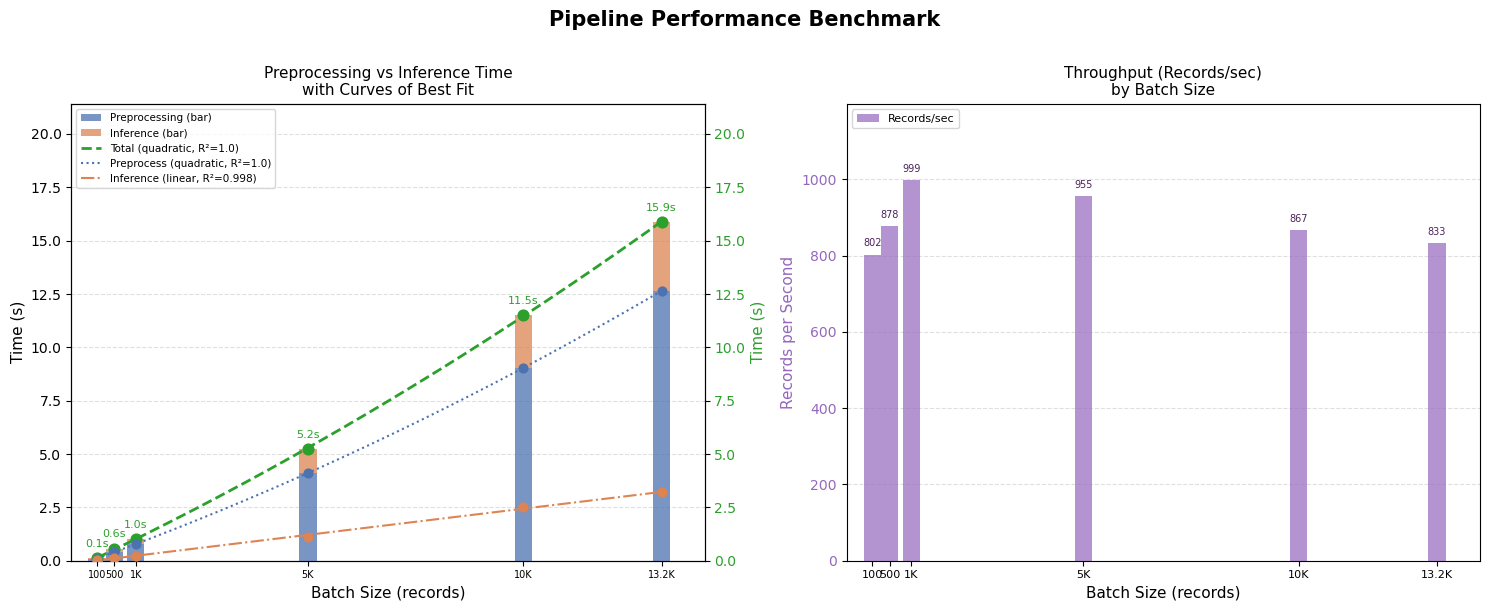

Benchmark plot saved -> C:\Users\polir\Downloads\SC4021 Assignment\sc4021-ir\data\cleaned\benchmark_plot.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# -------------------------------------------------------
# Benchmark data
# -------------------------------------------------------
batch_sizes     = [100, 500, 1000, 5000, 10000, 13214]
preprocess      = [0.0908, 0.4232, 0.7752, 4.1265, 9.0178, 12.6573]
inference       = [0.0338, 0.1462, 0.2261, 1.1081, 2.5112, 3.2084]
total           = [0.1246, 0.5695, 1.0013, 5.2346, 11.5291, 15.8656]
records_per_sec = [802.5, 878.0, 998.7, 955.2, 867.4, 832.9]

x        = np.array(batch_sizes, dtype=float)
x_smooth = np.linspace(x[0], x[-1], 500)

# -------------------------------------------------------
# Fit helpers
# -------------------------------------------------------
def poly_fit(y_values, degree=2):
    coeffs  = np.polyfit(x, y_values, degree)
    poly_fn = np.poly1d(coeffs)
    fitted  = poly_fn(x_smooth)
    y_pred  = poly_fn(x)
    ss_res  = np.sum((np.array(y_values) - y_pred) ** 2)
    ss_tot  = np.sum((np.array(y_values) - np.mean(y_values)) ** 2)
    r2      = 1 - ss_res / ss_tot if ss_tot != 0 else 1.0
    return fitted, round(r2, 3)

def linear_fit(y_values):
    coeffs  = np.polyfit(x, y_values, 1)
    poly_fn = np.poly1d(coeffs)
    fitted  = poly_fn(x_smooth)
    y_pred  = poly_fn(x)
    ss_res  = np.sum((np.array(y_values) - y_pred) ** 2)
    ss_tot  = np.sum((np.array(y_values) - np.mean(y_values)) ** 2)
    r2      = 1 - ss_res / ss_tot if ss_tot != 0 else 1.0
    return fitted, round(r2, 3)

total_fit, r2_total = poly_fit(total,      degree=2)
pre_fit,   r2_pre   = poly_fit(preprocess, degree=2)
inf_fit,   r2_inf   = linear_fit(inference)

bar_width = 400

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Pipeline Performance Benchmark",
             fontsize=15, fontweight="bold", y=1.01)

# -------------------------------------------------------
# LEFT PLOT — Stacked bar + curves
# -------------------------------------------------------
bars1 = ax1.bar(x, preprocess, width=bar_width,
                label="Preprocessing (bar)",
                color="#4C72B0", alpha=0.75, zorder=3)
bars2 = ax1.bar(x, inference, width=bar_width,
                label="Inference (bar)",
                bottom=preprocess,
                color="#DD8452", alpha=0.75, zorder=3)

ax1_twin = ax1.twinx()

ax1_twin.scatter(x, total,      color="#2ca02c", zorder=5, s=60)
ax1_twin.scatter(x, preprocess, color="#4C72B0", zorder=5, s=40)
ax1_twin.scatter(x, inference,  color="#DD8452", zorder=5, s=40)

ax1_twin.plot(x_smooth, total_fit, color="#2ca02c", linewidth=2,
              linestyle="--", zorder=4,
              label=f"Total (quadratic, R²={r2_total})")
ax1_twin.plot(x_smooth, pre_fit, color="#4C72B0", linewidth=1.5,
              linestyle=":", zorder=4,
              label=f"Preprocess (quadratic, R²={r2_pre})")
ax1_twin.plot(x_smooth, inf_fit, color="#DD8452", linewidth=1.5,
              linestyle="-.", zorder=4,
              label=f"Inference (linear, R²={r2_inf})")

for i, v in zip(x, total):
    ax1_twin.annotate(f"{v:.1f}s",
                      xy=(i, v),
                      xytext=(0, 8),
                      textcoords="offset points",
                      ha="center", fontsize=8, color="#2ca02c")

ax1_twin.set_ylabel("Time (s)", fontsize=11, color="#2ca02c")
ax1_twin.tick_params(axis="y", labelcolor="#2ca02c")
ax1_twin.set_ylim(0, max(total) * 1.35)

ax1.set_xticks(x)
ax1.set_xticklabels(["100", "500", "1K", "5K", "10K", "13.2K"], fontsize=7)
ax1.set_xlabel("Batch Size (records)", fontsize=11)
ax1.set_ylabel("Time (s)", fontsize=11)
ax1.set_xlim(-500, x[-1] + 1000)
ax1.set_title("Preprocessing vs Inference Time\nwith Curves of Best Fit", fontsize=11)
ax1.set_ylim(0, max(total) * 1.35)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

bar_handles          = [bars1, bars2]
bar_labels           = ["Preprocessing (bar)", "Inference (bar)"]
fit_handles, fit_lbs = ax1_twin.get_legend_handles_labels()
ax1.legend(bar_handles + fit_handles,
           bar_labels  + fit_lbs,
           loc="upper left", fontsize=7.5)

# -------------------------------------------------------
# RIGHT PLOT — Bar only, no line of best fit
# -------------------------------------------------------
bars3 = ax2.bar(x, records_per_sec, width=bar_width,
                color="#9467bd", alpha=0.7,
                label="Records/sec", zorder=2)

# Annotate bar tops with throughput values
for i, v in zip(x, records_per_sec):
    ax2.annotate(f"{v:.0f}",
                 xy=(i, v),
                 xytext=(0, 6),
                 textcoords="offset points",
                 ha="center", fontsize=7, color="#4a235a")

ax2.set_xticks(x)
ax2.set_xticklabels(["100", "500", "1K", "5K", "10K", "13.2K"], fontsize=8)
ax2.set_xlabel("Batch Size (records)", fontsize=11)
ax2.set_ylabel("Records per Second", fontsize=11, color="#9467bd")
ax2.tick_params(axis="y", labelcolor="#9467bd")
ax2.set_xlim(-500, x[-1] + 1000)
ax2.set_title("Throughput (Records/sec)\nby Batch Size", fontsize=11)
ax2.set_ylim(0, max(records_per_sec) * 1.2)
ax2.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax2.legend(loc="upper left", fontsize=8)

plt.tight_layout()

BENCHMARK_PLOT = OUTPUT_DIR / "benchmark_plot.png"
plt.savefig(BENCHMARK_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Benchmark plot saved -> {BENCHMARK_PLOT}")